# PaySim EDA

**Exploratory only.** This notebook is for understanding the data — no preprocessing, no
train/test splitting, no modeling here. Findings get written up separately in
`EDA_FINDINGS.md`.

Dataset: PaySim — Synthetic Financial Datasets For Fraud Detection
(https://www.kaggle.com/datasets/ealaxi/paysim1)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### Load data

Locate the repo root by walking up until a `.git` directory or the `.repo-root` marker file is found, so this works regardless of where Jupyter's working directory ends up.

In [ ]:
def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / ".git").exists() or (parent / ".repo-root").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (.git or .repo-root not found in any parent).")

REPO_ROOT = find_repo_root(Path.cwd())
RAW_DATA_DIR = REPO_ROOT / "ml" / "data" / "raw"
csv_path = next(RAW_DATA_DIR.glob("*.csv"))
print(f"Loading {csv_path}")

df = pd.read_csv(csv_path)
df.shape

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

## 1. Class distribution

This is the single most important number in the whole notebook — it drives sampling strategy,
metric choice (accuracy is useless here), and how we split train/test later.

In [5]:
fraud_counts = df["isFraud"].value_counts().sort_index()
fraud_pct = df["isFraud"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({"count": fraud_counts, "pct": fraud_pct})
summary.index = summary.index.map({0: "Not fraud", 1: "Fraud"})
print(summary)
print(f"\nFraud rate: {fraud_pct.loc[1]:.4f}%  ({fraud_counts.loc[1]:,} of {len(df):,} transactions)")

             count        pct
isFraud                      
Not fraud  6354407  99.870918
Fraud         8213   0.129082

Fraud rate: 0.1291%  (8,213 of 6,362,620 transactions)


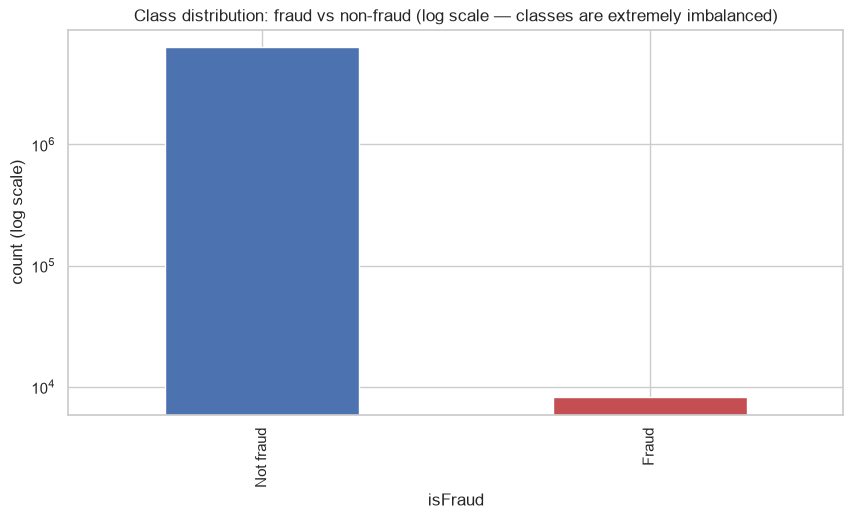

In [6]:
fig, ax = plt.subplots()
summary["count"].plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("count (log scale)")
ax.set_title("Class distribution: fraud vs non-fraud (log scale — classes are extremely imbalanced)")
plt.show()

## 2. Missing value analysis

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


## 3. Duplicate detection

In [8]:
full_row_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {full_row_dupes:,}")

# nameOrig should be a fairly clean per-customer identifier; check how often it repeats
name_orig_repeat_rate = (df["nameOrig"].value_counts() > 1).mean()
print(f"Share of nameOrig values that appear more than once: {name_orig_repeat_rate:.4%}")

Fully duplicated rows: 0


Share of nameOrig values that appear more than once: 0.1463%


## 4. Distribution of `amount`

Financial transaction amounts are almost always heavily right-skewed. Checking overall and
split by `isFraud`, with a log-scale view since the raw scale will be dominated by outliers.

In [9]:
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [10]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


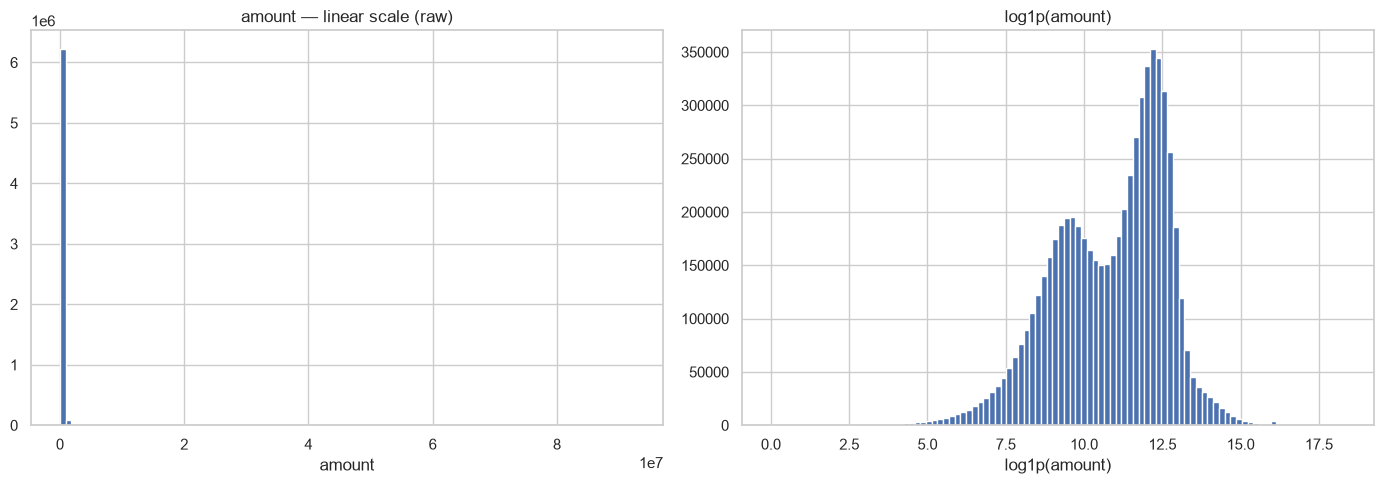

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["amount"], bins=100, color="#4C72B0")
axes[0].set_title("amount — linear scale (raw)")
axes[0].set_xlabel("amount")

log_amount = np.log1p(df["amount"])
axes[1].hist(log_amount, bins=100, color="#4C72B0")
axes[1].set_title("log1p(amount)")
axes[1].set_xlabel("log1p(amount)")

plt.tight_layout()
plt.show()

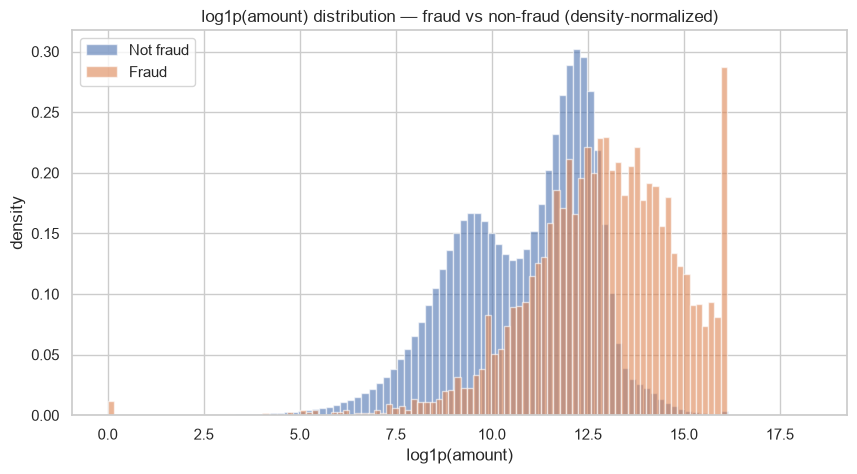

In [12]:
fig, ax = plt.subplots()
for label, group in df.groupby("isFraud"):
    ax.hist(np.log1p(group["amount"]), bins=100, alpha=0.6,
            density=True, label="Fraud" if label == 1 else "Not fraud")
ax.set_xlabel("log1p(amount)")
ax.set_ylabel("density")
ax.set_title("log1p(amount) distribution — fraud vs non-fraud (density-normalized)")
ax.legend()
plt.show()

## 5. Distribution and fraud rate by `type`

PaySim has five transaction types: `PAYMENT`, `TRANSFER`, `CASH_OUT`, `DEBIT`, `CASH_IN`.
Checking overall volume per type and fraud rate per type — commonly cited as concentrated in
specific types, verifying rather than assuming.

In [13]:
type_stats = df.groupby("type")["isFraud"].agg(["count", "sum", "mean"])
type_stats.columns = ["total_txns", "fraud_txns", "fraud_rate"]
type_stats["fraud_rate_pct"] = (type_stats["fraud_rate"] * 100).round(4)
type_stats = type_stats.sort_values("fraud_txns", ascending=False)
type_stats

,total_txns,fraud_txns,fraud_rate,fraud_rate_pct
type,,,,
CASH_OUT,2237500,4116,0.001840,0.1840
TRANSFER,532909,4097,0.007688,0.7688
CASH_IN,1399284,0,0.000000,0.0000
DEBIT,41432,0,0.000000,0.0000
PAYMENT,2151495,0,0.000000,0.0000


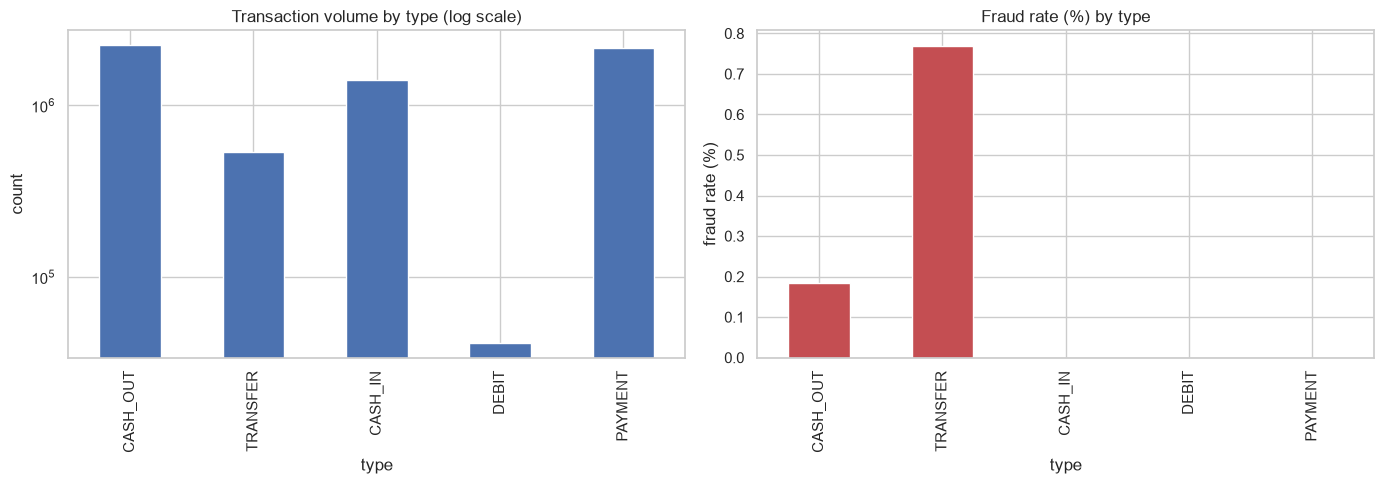

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_stats["total_txns"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_yscale("log")
axes[0].set_title("Transaction volume by type (log scale)")
axes[0].set_ylabel("count")

type_stats["fraud_rate_pct"].plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Fraud rate (%) by type")
axes[1].set_ylabel("fraud rate (%)")

plt.tight_layout()
plt.show()

In [15]:
types_with_any_fraud = type_stats.loc[type_stats["fraud_txns"] > 0].index.tolist()
print(f"Transaction types with at least one fraud case: {types_with_any_fraud}")

Transaction types with at least one fraud case: ['CASH_OUT', 'TRANSFER']


## 6. Time-based patterns via `step`

`step` = 1 simulated hour; the dataset spans 744 steps (~31 days). Deriving hour-of-day
(`step % 24`) and day to check for time-of-day / day patterns in fraud rate.

In [16]:
df["hour_of_day"] = df["step"] % 24
df["day"] = df["step"] // 24
print(f"step range: {df['step'].min()} to {df['step'].max()}  ->  ~{df['step'].max() / 24:.1f} days")

step range: 1 to 743  ->  ~31.0 days


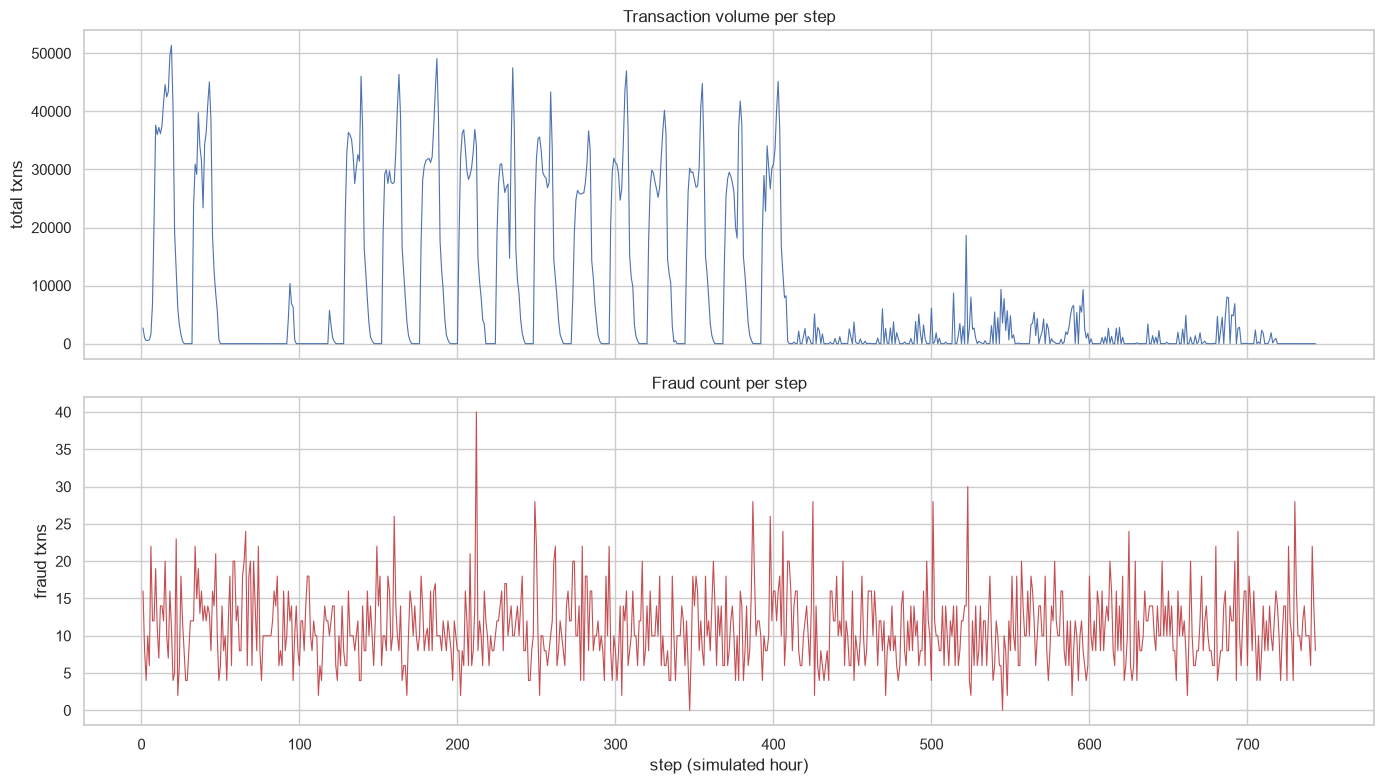

In [17]:
fraud_by_step = df.groupby("step")["isFraud"].agg(["count", "sum", "mean"])
fraud_by_step.columns = ["total_txns", "fraud_txns", "fraud_rate"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(fraud_by_step.index, fraud_by_step["total_txns"], color="#4C72B0", linewidth=0.8)
axes[0].set_ylabel("total txns")
axes[0].set_title("Transaction volume per step")

axes[1].plot(fraud_by_step.index, fraud_by_step["fraud_txns"], color="#C44E52", linewidth=0.8)
axes[1].set_ylabel("fraud txns")
axes[1].set_xlabel("step (simulated hour)")
axes[1].set_title("Fraud count per step")

plt.tight_layout()
plt.show()

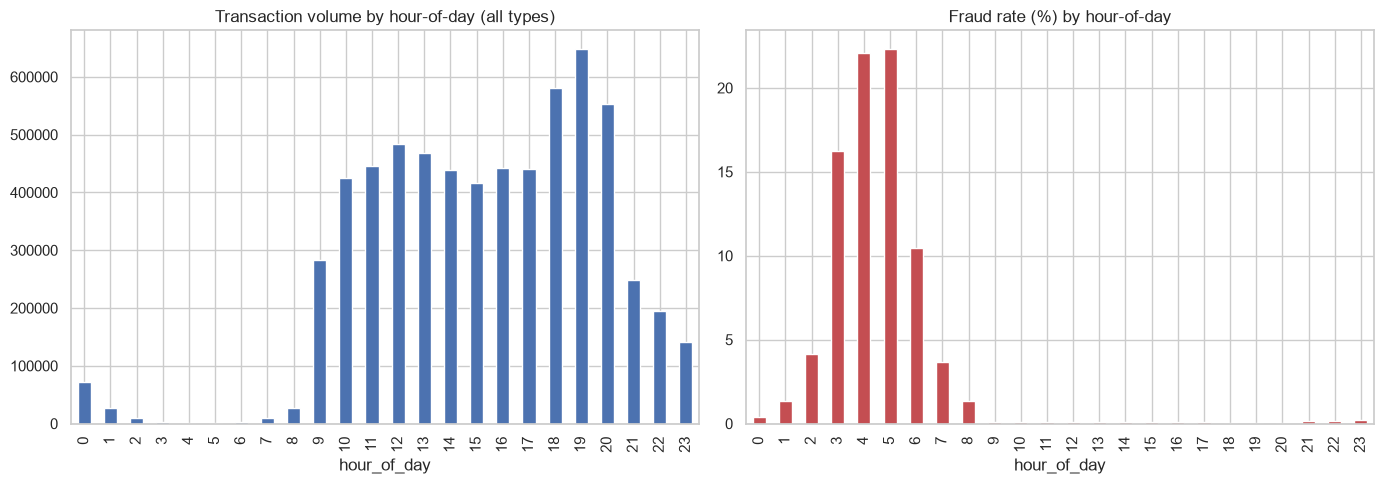

,total_txns,fraud_txns,fraud_rate,fraud_rate_pct
hour_of_day,,,,
0,71587,300,0.004191,0.419071
1,27111,358,0.013205,1.320497
2,9018,372,0.041251,4.125083
3,2007,326,0.162431,16.243149
4,1241,274,0.220790,22.078969
5,1641,366,0.223035,22.303473
6,3420,358,0.104678,10.467836
7,8988,328,0.036493,3.649310
8,26915,368,0.013673,1.367267


In [18]:
fraud_by_hour = df.groupby("hour_of_day")["isFraud"].agg(["count", "sum", "mean"])
fraud_by_hour.columns = ["total_txns", "fraud_txns", "fraud_rate"]
fraud_by_hour["fraud_rate_pct"] = fraud_by_hour["fraud_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fraud_by_hour["total_txns"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Transaction volume by hour-of-day (all types)")

fraud_by_hour["fraud_rate_pct"].plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Fraud rate (%) by hour-of-day")

plt.tight_layout()
plt.show()
fraud_by_hour

Restricting the hour-of-day view to the transaction types that actually carry fraud (from section 5), since PAYMENT/DEBIT/CASH_IN volume with zero fraud would dilute the picture otherwise.

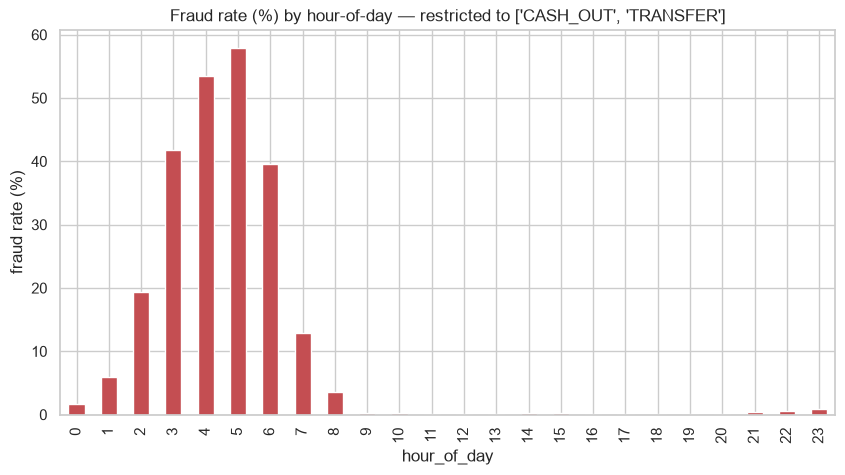

In [19]:
fraud_types_df = df[df["type"].isin(types_with_any_fraud)]
fraud_by_hour_relevant = fraud_types_df.groupby("hour_of_day")["isFraud"].mean() * 100

fig, ax = plt.subplots()
fraud_by_hour_relevant.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title(f"Fraud rate (%) by hour-of-day — restricted to {types_with_any_fraud}")
ax.set_ylabel("fraud rate (%)")
plt.show()

## 7. Balance consistency checks

For a normal transfer, we'd expect:

- `newbalanceOrig` ≈ `oldbalanceOrg` - `amount` (money leaves the origin account)
- `newbalanceDest` ≈ `oldbalanceDest` + `amount` (money arrives at the destination account)

Computing the signed error for both and checking how often — and by how much — reality departs
from that expectation, split by `isFraud`. Large, systematic, non-fraud-specific deviations here
would be a red flag: an engineered "error" feature that's actually just encoding a simulation
artifact (e.g. merchant accounts never tracked) is a leakage/overfitting trap, not a real fraud
signal.

In [20]:
df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

orig_consistent = np.isclose(df["errorBalanceOrig"], 0, atol=1e-2)
dest_consistent = np.isclose(df["errorBalanceDest"], 0, atol=1e-2)

print("Origin-side balance consistency (newbalanceOrig == oldbalanceOrg - amount):")
print(pd.crosstab(df["isFraud"], orig_consistent, rownames=["isFraud"], colnames=["consistent"]))

print("\nDestination-side balance consistency (newbalanceDest == oldbalanceDest + amount):")
print(pd.crosstab(df["isFraud"], dest_consistent, rownames=["isFraud"], colnames=["consistent"]))

Origin-side balance consistency (newbalanceOrig == oldbalanceOrg - amount):


consistent    False    True 
isFraud                     
0           5077646  1276761
1                45     8168

Destination-side balance consistency (newbalanceDest == oldbalanceDest + amount):


consistent    False    True 
isFraud                     
0           4184007  2170400
1              4640     3573


In [21]:
print("errorBalanceOrig by isFraud:")
print(df.groupby("isFraud")["errorBalanceOrig"].describe())

print("\nerrorBalanceDest by isFraud:")
print(df.groupby("isFraud")["errorBalanceDest"].describe())

errorBalanceOrig by isFraud:


             count           mean            std          min        25%  \
isFraud                                                                    
0        6354407.0 -201338.558109  606928.890826 -92445516.64 -249953.43   
1           8213.0  -10692.325265  265146.131130 -10000000.00       0.00   

              50%       75%           max  
isFraud                                    
0       -69049.31 -3034.305  1.000000e-02  
1            0.00     0.000  3.725290e-09  

errorBalanceDest by isFraud:


             count           mean           std          min  25%      50%  \
isFraud                                                                      
0        6354407.0   54692.231734  4.360026e+05 -75885725.63  0.0  3500.68   
1           8213.0  732509.301069  1.867748e+06  -8875516.29  0.0  2231.46   

                75%          max  
isFraud                           
0         29259.805  13191233.98  
1        442722.010  10000000.00  


Checking whether destination-side inconsistency lines up with merchant accounts (`nameDest` starting with `M`), which PaySim documentation says never have tracked balances — a likely explanation for a lot of the destination-side "error" if so.

In [22]:
df["dest_is_merchant"] = df["nameDest"].str.startswith("M")

print("Merchant destination balance values (oldbalanceDest, newbalanceDest) — expect ~always 0 if untracked:")
print(df.loc[df["dest_is_merchant"], ["oldbalanceDest", "newbalanceDest"]].describe())

print("\ndest_is_merchant by type:")
print(pd.crosstab(df["type"], df["dest_is_merchant"]))

Merchant destination balance values (oldbalanceDest, newbalanceDest) — expect ~always 0 if untracked:


       oldbalanceDest  newbalanceDest
count       2151495.0       2151495.0
mean              0.0             0.0
std               0.0             0.0
min               0.0             0.0
25%               0.0             0.0
50%               0.0             0.0
75%               0.0             0.0
max               0.0             0.0

dest_is_merchant by type:


dest_is_merchant    False    True 
type                              
CASH_IN           1399284        0
CASH_OUT          2237500        0
DEBIT               41432        0
PAYMENT                 0  2151495
TRANSFER           532909        0


In [23]:
zero_balance_orig = (df["oldbalanceOrg"] == df["amount"]) & (df["newbalanceOrig"] == 0)
print("Share of transactions where oldbalanceOrg == amount and newbalanceOrig == 0 "
      "(origin account fully drained), by isFraud:")
print(df.groupby("isFraud").apply(lambda g: (
    (g["oldbalanceOrg"] == g["amount"]) & (g["newbalanceOrig"] == 0)
).mean(), include_groups=False))

Share of transactions where oldbalanceOrg == amount and newbalanceOrig == 0 (origin account fully drained), by isFraud:


isFraud
0    0.000000
1    0.976988
dtype: float64


## 8. Correlation analysis among numeric fields

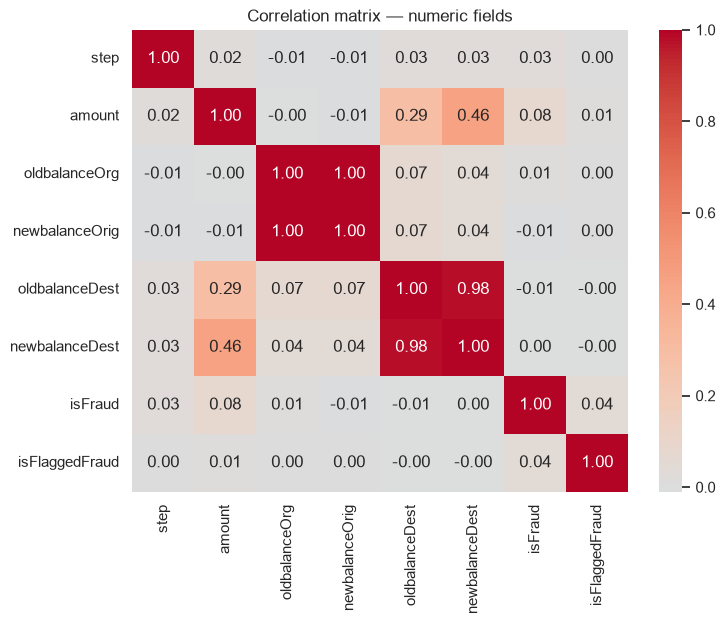

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

In [24]:
numeric_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
                 "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix — numeric fields")
plt.show()

corr["isFraud"].sort_values(ascending=False)

## 9. `isFlaggedFraud` vs `isFraud`

PaySim's documentation claims `isFlaggedFraud` marks an attempt to transfer more than 200,000
in a single transaction. Rather than taking that at face value, checking empirically: how often
do the two labels agree, and what actually distinguishes the rows where `isFlaggedFraud == 1`?

In [25]:
print("Cross-tab of isFraud vs isFlaggedFraud:")
print(pd.crosstab(df["isFraud"], df["isFlaggedFraud"]))

n_flagged = (df["isFlaggedFraud"] == 1).sum()
print(f"\nTotal isFlaggedFraud == 1 rows: {n_flagged}")

Cross-tab of isFraud vs isFlaggedFraud:


isFlaggedFraud        0   1
isFraud                    
0               6354407   0
1                  8197  16

Total isFlaggedFraud == 1 rows: 16


In [26]:
flagged = df[df["isFlaggedFraud"] == 1]
print("Rows where isFlaggedFraud == 1:")
flagged[["step", "type", "amount", "oldbalanceOrg", "newbalanceOrig", "isFraud"]]

Rows where isFlaggedFraud == 1:


,step,type,amount,oldbalanceOrg,newbalanceOrig,isFraud
2736446,212,TRANSFER,4953893.08,4953893.08,4953893.08,1
3247297,250,TRANSFER,1343002.08,1343002.08,1343002.08,1
3760288,279,TRANSFER,536624.41,536624.41,536624.41,1
5563713,387,TRANSFER,4892193.09,4892193.09,4892193.09,1
5996407,425,TRANSFER,10000000.00,19585040.37,19585040.37,1
5996409,425,TRANSFER,9585040.37,19585040.37,19585040.37,1
6168499,554,TRANSFER,3576297.10,3576297.10,3576297.10,1
6205439,586,TRANSFER,353874.22,353874.22,353874.22,1
6266413,617,TRANSFER,2542664.27,2542664.27,2542664.27,1
6281482,646,TRANSFER,10000000.00,10399045.08,10399045.08,1


In [27]:
# Test the documented rule directly: TRANSFER with amount > 200,000
rule_matches = df[(df["type"] == "TRANSFER") & (df["amount"] > 200_000)]
print(f"TRANSFERs with amount > 200,000: {len(rule_matches):,}")
print(f"Of those, isFlaggedFraud == 1: {(rule_matches['isFlaggedFraud'] == 1).sum():,}")
print(f"Of those, isFraud == 1: {(rule_matches['isFraud'] == 1).sum():,}")

TRANSFERs with amount > 200,000: 409,110
Of those, isFlaggedFraud == 1: 16
Of those, isFraud == 1: 2,740


### Notebook complete

See `EDA_FINDINGS.md` in this folder for the written-up summary of what these results mean for the feature schema and modeling plan.